## Dataset Variables

The columns in O2O2_collisions.csv represent the following variables:

| Column | Variable |
|--------|----------|
| 0 | v1_in(1) |
| 1 | v1_in(2) |
| 2 | v1_in(3) |
| 3 | v2_in(1) |
| 4 | v2_in(2) |
| 5 | v2_in(3) |
| 6 | omega1_in(1) |
| 7 | omega1_in(2) |
| 8 | omega1_in(3) |
| 9 | omega2_in(1) |
| 10 | omega2_in(2) |
| 11 | omega2_in(3) |
| 12 | v1_out(1) |
| 13 | v1_out(2) |
| 14 | v1_out(3) |
| 15 | v2_out(1) |
| 16 | v2_out(2) |
| 17 | v2_out(3) |
| 18 | omega1_out(1) |
| 19 | omega1_out(2) |
| 20 | omega1_out(3) |
| 21 | omega2_out(1) |
| 22 | omega2_out(2) |
| 23 | omega2_out(3) |

# Mixeture Density Networks (MDN)

A Mixture Density Network (MDN) predicts means, variances, and mixture coefficients for a mixture of Gaussian distributions, allowing it to model complex output distributions conditioned on input features. This is particularly useful for modeling the scattering kernel in our oxygen dataset, where the output velocity distributions depend on the input velocities.

The MDN creates a model that predicts conditional probabilities using
$$ 
p(y|x) = \sum_{i=1}^{K} \pi_i(x) \mathcal{N}(y|\mu_i(x), \sigma_i(x)) 
$$
where $K$ is the number of mixture components, $\pi_i(x)$ are the mixture coefficients, and $\mathcal{N}(y|\mu_i(x), \sigma_i(x))$ are Gaussian distributions with means $\mu_i(x)$ and standard deviations $\sigma_i(x)$.

The dimensions of each variable is:
$\pi$: K
$\mu$: K x D
$\sigma$: K x D
where D is the output dimension.

#### Dataset Preparation

In [41]:
import numpy as np

DATA = "../data_aldo/Run/H2H2_collisions_benjamin.csv"
rawdata = np.loadtxt(DATA, delimiter=',', skiprows=1)

# Convert to the variable set (Ec, \eta_trans, \eta_rot_A)
inputdata = np.zeros((rawdata.shape[0], 3))
inputdata[:,0] = np.sum(rawdata[:,1:4], axis=1)
inputdata[:,1] = rawdata[:,1]/inputdata[:,0] 
inputdata[:,2] = rawdata[:,2] / np.sum(rawdata[:,2:4], axis=1)

outputdata = np.zeros((rawdata.shape[0], 3))
outputdata[:,0] = np.sum(rawdata[:,4:7], axis=1)
outputdata[:,1] = rawdata[:,4]/outputdata[:,0]
outputdata[:,2] = rawdata[:,5]/ np.sum(rawdata[:,5:7], axis=1)

In [42]:
# Create Dataloaders for training and validation (with normalization)
import torch
from torch.utils.data import DataLoader, TensorDataset, Subset

inputs = torch.tensor(inputdata, dtype=torch.float32)
outputs = torch.tensor(outputdata, dtype=torch.float32)

dataset = TensorDataset(inputs, outputs)

train_size = int(0.7 * len(dataset))
val_size = len(dataset) - train_size

# Reproducible split (avoid val-stat leakage into normalization)
generator = torch.Generator().manual_seed(0)
train_subset, val_subset = torch.utils.data.random_split(dataset, [train_size, val_size], generator=generator)

train_idx = torch.tensor(train_subset.indices, dtype=torch.long)
val_idx = torch.tensor(val_subset.indices, dtype=torch.long)

# Compute normalization statistics on training data only
eps = 1e-8
in_mean = inputs[train_idx].mean(dim=0, keepdim=True)
in_std = inputs[train_idx].std(dim=0, unbiased=False, keepdim=True).clamp_min(eps)
out_mean = outputs[train_idx].mean(dim=0, keepdim=True)
out_std = outputs[train_idx].std(dim=0, unbiased=False, keepdim=True).clamp_min(eps)

# Normalize full tensors, then re-wrap using the same split indices
inputs_norm = (inputs - in_mean) / in_std
outputs_norm = (outputs - out_mean) / out_std
dataset_norm = TensorDataset(inputs_norm, outputs_norm)

train_dataset = Subset(dataset_norm, train_idx.tolist())
val_dataset = Subset(dataset_norm, val_idx.tolist())

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

print("Input mean:", in_mean.flatten().tolist())
print("Input std :", in_std.flatten().tolist())
print("Output mean:", out_mean.flatten().tolist())
print("Output std :", out_std.flatten().tolist())

Input mean: [6049.673828125, 0.4815983474254608, 0.5023599863052368]
Input std : [2097.983154296875, 0.1984938532114029, 0.23896823823451996]
Output mean: [6049.6318359375, 0.48537585139274597, 0.5032348036766052]
Output std : [2097.997802734375, 0.21043580770492554, 0.25154367089271545]


#### Model Definition

In [43]:
import torch.nn as nn
import torch.nn.functional as F

class MixtureDensityNetwork(nn.Module):
    def __init__(self, input_dim, output_dim, num_mixtures, hidden_dim=128):
        super().__init__()
        self.K = num_mixtures
        self.D = output_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.pi_layer = nn.Linear(hidden_dim, self.K)
        self.mu_layer = nn.Linear(hidden_dim, self.K * self.D)
        self.sigma_layer = nn.Linear(hidden_dim, self.K * self.D)

    def forward(self, x):
        h = self.net(x)

        # Mixture weights
        pi = F.softmax(self.pi_layer(h), dim=-1)

        # Means
        mu = self.mu_layer(h)
        mu = mu.view(-1, self.K, self.D)

        # Standard deviations
        sigma = self.sigma_layer(h)
        sigma = F.softplus(sigma) + 1e-6  # Ensure positivity
        # sigma = torch.exp(sigma)
        sigma = sigma.view(-1, self.K, self.D)

        return pi, mu, sigma

#### Define loss function

In [44]:
def mdn_loss(pi, mu, sigma, y):
    """
    Computes the negative log-likelihood loss for a Mixture Density Network.
    Args:
        pi: Mixture weights, shape (batch_size, K)
        mu: Means of the mixtures, shape (batch_size, K, D)
        sigma: Standard deviations of the mixtures, shape (batch_size, K, D)
        y: Target values, shape (batch_size, D)
    """
    y = y.unsqueeze(1)  # Shape (batch_size, 1, D)

    # Gaussian probability density function
    log_prob = -0.5 * (
        torch.sum(((y - mu) / sigma) ** 2, dim=2)
        + torch.sum(torch.log(sigma ** 2), dim=2)
        + mu.size(2) * torch.log(torch.tensor(2 * torch.pi))
    )  # Shape (batch_size, K)

    # Weighted log probabilities
    weighted_log_prob = log_prob + torch.log(pi + 1e-8)
    log_sum_exp = torch.logsumexp(weighted_log_prob, dim=1) 

    return -torch.mean(log_sum_exp)

#### Training

In [46]:
K = 5
output_dim = 3

model = MixtureDensityNetwork(
    input_dim=3,
    output_dim=output_dim,
    num_mixtures=K
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 50
train_loss_hist = np.zeros(num_epochs)
val_loss_hist = np.zeros(num_epochs)

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0.0
    for inputs, outputs in train_loader:
        optimizer.zero_grad()
        pi, mu, sigma = model(inputs)
        loss = mdn_loss(pi, mu, sigma, outputs)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_loss_hist[epoch] = train_loss
    print(f"Epoch {epoch+1}, Training Loss: {train_loss:.4f}")

    # Validation
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        for inputs, outputs in val_loader:
            pi, mu, sigma = model(inputs)
            loss = mdn_loss(pi, mu, sigma, outputs)
            val_loss += loss.item()

        val_loss /= len(val_loader)
        val_loss_hist[epoch] = val_loss
    print(f"Epoch {epoch+1}, Validation Loss: {val_loss_hist[epoch]:.4f}")

torch.save(model.state_dict(), "mdn_o2o2_collision_model.pth")

Epoch 1, Training Loss: 4.4409
Epoch 1, Validation Loss: 4.1181
Epoch 2, Training Loss: 3.8511
Epoch 2, Validation Loss: 3.6197
Epoch 3, Training Loss: 3.3498
Epoch 3, Validation Loss: 3.0386
Epoch 4, Training Loss: 2.5115
Epoch 4, Validation Loss: 1.8049
Epoch 5, Training Loss: 1.0781
Epoch 5, Validation Loss: 0.4086
Epoch 6, Training Loss: 0.1152
Epoch 6, Validation Loss: 0.0541
Epoch 7, Training Loss: -0.2362
Epoch 7, Validation Loss: -0.3712
Epoch 8, Training Loss: -0.4935
Epoch 8, Validation Loss: -0.6058
Epoch 9, Training Loss: -0.6444
Epoch 9, Validation Loss: -0.7578
Epoch 10, Training Loss: -0.7777
Epoch 10, Validation Loss: -0.5278
Epoch 11, Training Loss: -0.6330
Epoch 11, Validation Loss: -0.9144
Epoch 12, Training Loss: -0.8683
Epoch 12, Validation Loss: -0.7052
Epoch 13, Training Loss: -0.7395
Epoch 13, Validation Loss: -0.7803
Epoch 14, Training Loss: -0.9286
Epoch 14, Validation Loss: -1.0006
Epoch 15, Training Loss: -0.9891
Epoch 15, Validation Loss: -1.1621
Epoch 16, 

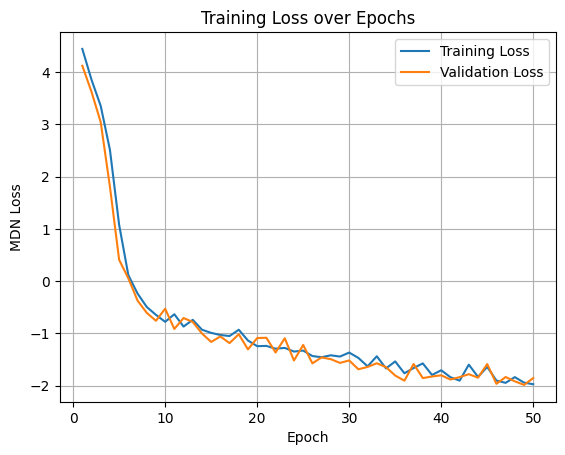

In [47]:
import matplotlib.pyplot as plt

plt.plot(range(1, num_epochs + 1), train_loss_hist, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_loss_hist, label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('MDN Loss')
plt.title('Training Loss over Epochs')
plt.grid()
plt.show()